MSE : 5.40916038414398
R2 Score : 0.9945485911976377

Cross Validation Scores:
[-21.20114087  -4.39       -25.86176857]

Average Neg MSE:
-17.150969815441034


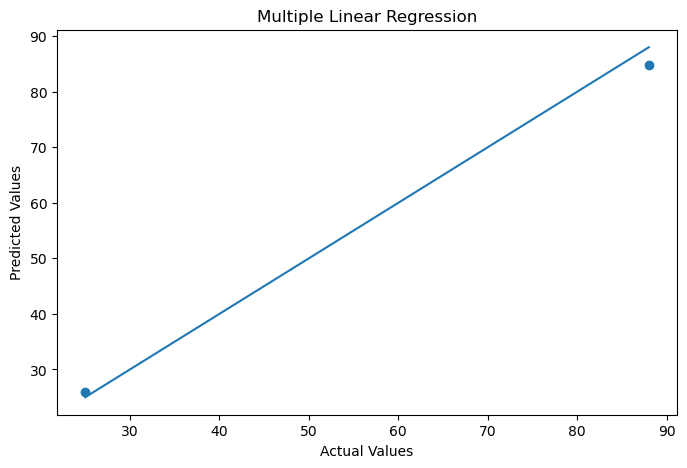

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = {
    'Hours':[1,2,3,4,5,6,7,8,9,10],
    'Attendance':[60,65,70,72,75,80,85,88,90,95],
    'PreviousMarks':[40,45,50,55,60,65,70,75,80,85],
    'Score':[20,25,35,40,50,58,68,78,88,95]
}

df = pd.DataFrame(data)

X = df[['Hours','Attendance','PreviousMarks']]
y = df['Score']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# Cross Validation
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=3
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage Neg MSE:")
print(cv_scores.mean())

# Actual vs Predicted Plot
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")

plt.show()